<a href="https://colab.research.google.com/github/sauravpatil045/MLOPS1.THIRD-YEAR/blob/main/MIL4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15600000    Male   41            71570          1
1  15600001  Female   28            16015          1
2  15600002    Male   25            76813          0
3  15600003    Male   53            42712          1
4  15600004    Male   55           115497          1


In [3]:
print(df.shape) #(rows, columns)

(400, 5)


In [4]:
df['Purchased'].value_counts()

,count
Purchased,
1,260
0,140


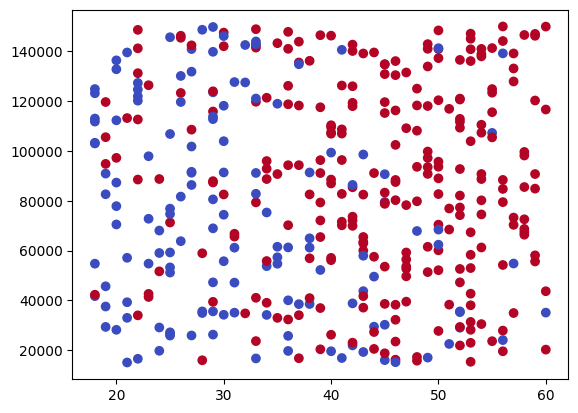

In [5]:
# Scatter Plot to show Unlinear data
plt.scatter(df['Age'], df['EstimatedSalary'], cmap='coolwarm', c=df['Purchased'])

In [6]:
X = df[['Age', 'EstimatedSalary']] #Features
y = df['Purchased'] #Target

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler() # mean=0, std=1
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1])

In [10]:
# Classifiaction report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7375


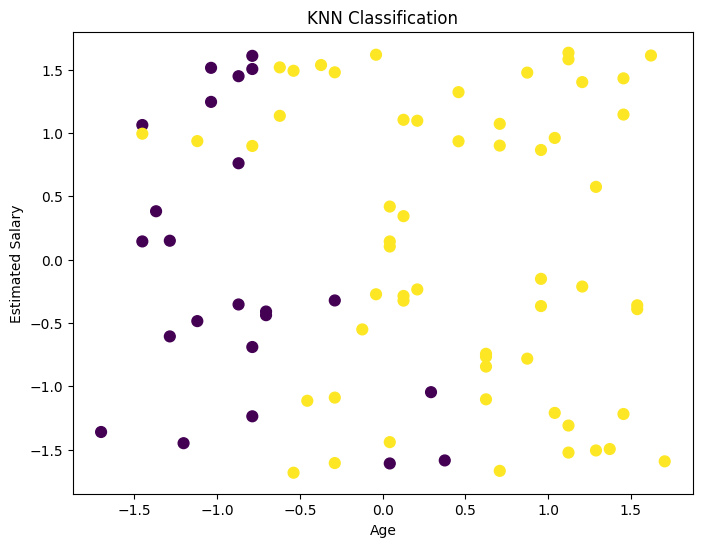

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_pred, cmap='viridis', s=60,)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('KNN Classification')
plt.show()

In [12]:
k_values = range(1,16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print("k =", k, "Accuracy =", round(accuracy, 3))

k = 1 Accuracy = 0.725
k = 2 Accuracy = 0.713
k = 3 Accuracy = 0.775
k = 4 Accuracy = 0.762
k = 5 Accuracy = 0.738
k = 6 Accuracy = 0.75
k = 7 Accuracy = 0.75
k = 8 Accuracy = 0.762
k = 9 Accuracy = 0.738
k = 10 Accuracy = 0.75
k = 11 Accuracy = 0.775
k = 12 Accuracy = 0.8
k = 13 Accuracy = 0.775
k = 14 Accuracy = 0.8
k = 15 Accuracy = 0.775


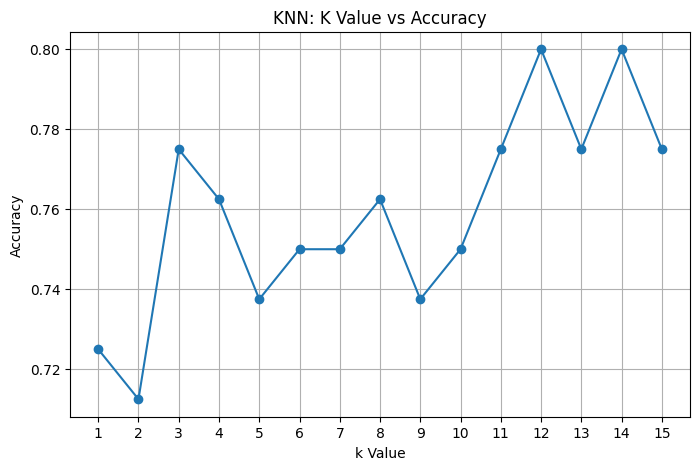

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o') #Line Plot

plt.xlabel("k Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Value vs Accuracy")

plt.xticks(k_values)
plt.grid()
plt.show()

In [14]:
# Finding best k and accuracy value
best_k = k_values[accuracies.index(max(accuracies))]
print("Best k:", best_k)
print("Best accuracy:", max(accuracies))

Best k: 12
Best accuracy: 0.8
